# 📊 Notebook 03 — EDA Univariate Profile

---

<div style="background: linear-gradient(135deg, #0f0c29 0%, #302b63 50%, #24243e 100%); padding: 24px 28px; border-radius: 16px; margin: 12px 0; border: 1px solid #e94560;">
<h2 style="color: #e94560; margin: 0 0 8px 0; font-size: 1.4em;">📊 EDA Univariate Profile</h2>
<h3 style="color: #a8dadc; margin: 0 0 16px 0; font-weight: 400; font-size: 1.05em;">Fase A — Fondasi Data dan Eksperimen</h3>
<hr style="border: none; border-top: 1px solid #444; margin: 12px 0;">
<table style="color: #ccc; font-size: 0.9em; border-collapse: collapse; width: 100%;">
<tr><td style="padding: 4px 16px 4px 0; white-space:nowrap;">📍 Studi Kasus</td><td><strong style="color: #fff;">PT. XYZ Banjarmasin, Kalimantan Selatan</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">🎓 Mata Kuliah</td><td><strong style="color: #fff;">Tugas Akhir — ES234733</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">🏛 Institusi</td><td><strong style="color: #fff;">Departemen Sistem Informasi, FTEIC — ITS Surabaya</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">👤 Penulis</td><td><strong style="color: #fff;">Muhammad Iqbal Baiduri Yamani — NRP 5026221103</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">🧑‍🏫 Pembimbing</td><td><strong style="color: #fff;">Edwin Riksakomara, S.Kom., M.T.</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">📅 Tahun</td><td><strong style="color: #fff;">2025</strong></td></tr>
</table>
</div>

## 📌 Tujuan Notebook Ini

Notebook 03 melakukan **Exploratory Data Analysis (EDA) univariat** terhadap kolom target `Grand Total` dari dataset penjualan mingguan mie instan **sebelum pra-proses**. Analisis ini bertujuan memahami distribusi, tren temporal, dan karakteristik statistik data mentah sebagai dasar pengambilan keputusan preprocessing di Notebook 04.

| # | Tahapan | Keterangan |
|---|---------|------------|
| 1 | **Import & Setup** | Muat library, seed `GLOBAL_SEED = 42`, dan PATHS |
| 2 | **Load Data** | Reload file `.xlsx` → `df_sorted` (364 × 3) |
| 3 | **Statistik Deskriptif** | `count`, `mean`, `std`, `min`, `max`, Q1, Q3, skewness, kurtosis |
| 4 | **Line Chart Tren Waktu** | Visualisasi fluktuasi penjualan 2019–2025 |
| 5 | **Distribusi & Boxplot** | Identifikasi visual outlier dan pola distribusi |
| 6 | **Insight Data** | Ringkasan temuan EDA + deteksi outlier IQR |
| 7 | **Simpan Artefak** | Catat profil EDA ke `logs/eda_profile.json` |
| 8 | **Checklist** | Verifikasi semua item Pipeline.md Gate 2 terpenuhi |

---

### 🔬 Konteks EDA

**Sumber:** Dataset terurut hasil audit Notebook 02 — shape (364, 3), kolom: `Year`, `Week`, `Grand Total`.

**Alur Analisis di Notebook Ini:**

```mermaid
flowchart LR
    A["📊 df_sorted: 364×3"] --> B["Statistik Deskriptif"]
    B --> C["Line Chart Tren 2019–2025"]
    C --> D["Boxplot + Distribusi"]
    D --> E{"Ada Outlier<br/>IQR?"}
    E -- "✅ Ya" --> F["📋 Catat & Laporkan"]
    E -- "✅ Tidak" --> G["💾 eda_profile.json"]
    F --> G
    G --> H["✅ EDA Selesai"]
    H --> I["➡️ Notebook 04"]
```

| Aspek | Detail |
|-------|--------|
| **File Input** | `data/Dataset_Raw_Top 1 Sales 2019 - 2025.xlsx` |
| **Sheet** | `Target_Product_Weekly` |
| **Kolom Target** | `Grand Total` (volume penjualan, satuan: karton) |
| **Periode Data** | 2019–2025, frekuensi mingguan |
| **Jumlah Observasi** | 364 minggu (52 minggu × 7 tahun) |
| **Output Notebook** | `df_sorted` (terurut), `eda_profile` (dict), 2 figur PNG |

## ⚙️ 1. Import Library & Setup

In [1]:
# ── Import Library & Setup ────────────────────────────────────
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

# ── Deteksi Environment & Path Konfigurasi ────────────────────
IS_COLAB = False
ROOT_DIR = Path(".").resolve().parent

EXCEL_FILE = "Dataset_Raw_Top 1 Sales 2019 - 2025.xlsx"
EXCEL_PATH = ROOT_DIR / "data" / EXCEL_FILE

PATHS = {
    "root"        : ROOT_DIR,
    "data"        : ROOT_DIR / "data",
    "logs"        : ROOT_DIR / "logs",
    "outputs"     : ROOT_DIR / "outputs",
    "figures"     : ROOT_DIR / "outputs" / "figures",
    "models"      : ROOT_DIR / "outputs" / "models",
    "metrics"     : ROOT_DIR / "outputs" / "metrics",
    "splits"      : ROOT_DIR / "outputs" / "splits",
    "cv_folds"    : ROOT_DIR / "outputs" / "cv_folds",
    "checkpoints" : ROOT_DIR / "outputs" / "checkpoints",
    "reports"     : ROOT_DIR / "outputs" / "reports",
    "assets"      : ROOT_DIR / "outputs" / "assets",
    "notebooks"   : ROOT_DIR / "notebook",
}

for p in PATHS.values():
    if isinstance(p, Path):
        p.mkdir(parents=True, exist_ok=True)

# ── Matplotlib Style ──────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor"  : "#1a1a2e",
    "axes.facecolor"    : "#16213e",
    "axes.edgecolor"    : "#444",
    "axes.labelcolor"   : "#ccc",
    "xtick.color"       : "#aaa",
    "ytick.color"       : "#aaa",
    "text.color"        : "#ddd",
    "grid.color"        : "#2a2a4a",
    "grid.linestyle"    : "--",
    "grid.alpha"        : 0.5,
    "figure.dpi"        : 100,
})

# ── Konstanta Penelitian ──────────────────────────────────────
SHEET_NAME    = "Target_Product_Weekly"
REQUIRED_COLS = ["Year", "Week", "Grand Total"]
TAU           = 8          # lag/horizon peramalan
WEEKS_PER_YR  = 52         # minggu standar per tahun

print("=" * 60)
print("  SETUP — NOTEBOOK 03")
print("=" * 60)
print("\n  Env          : Lokal")
print(f"  GLOBAL_SEED  : {GLOBAL_SEED}")
print(f"  ROOT_DIR     : {ROOT_DIR}")
print(f"  EXCEL_PATH   : {EXCEL_PATH}")
print(f"  SHEET_NAME   : {SHEET_NAME}")
print(f"  TAU (horizon): {TAU} minggu")
print(f"  NumPy        : {np.__version__}")
print(f"  Pandas       : {pd.__version__}")
print(f"  Matplotlib   : {matplotlib.__version__}")
print(f"  Seaborn      : {sns.__version__}")
print()
print("  ✅ Setup selesai. Siap EDA Univariate Profile.")
print("=" * 60)


  SETUP — NOTEBOOK 03

  Env          : Lokal
  GLOBAL_SEED  : 42
  ROOT_DIR     : C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting
  EXCEL_PATH   : C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\data\Dataset_Raw_Top 1 Sales 2019 - 2025.xlsx
  SHEET_NAME   : Target_Product_Weekly
  TAU (horizon): 8 minggu
  NumPy        : 2.4.4
  Pandas       : 3.0.2
  Matplotlib   : 3.10.9
  Seaborn      : 0.13.2

  ✅ Setup selesai. Siap EDA Univariate Profile.


## 📥 2. Load Data

In [2]:
# ── Load dan Urutkan Data ─────────────────────────────────────
df_raw = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME)
df_raw.columns = df_raw.columns.str.strip()

# Urutkan ulang seperti hasil audit NB02
df_sorted = df_raw.sort_values(["Year", "Week"], ascending=[True, True]).reset_index(drop=True)

print("=" * 60)
print("  LOAD DATA — NOTEBOOK 03")
print("=" * 60)
print(f"  df_raw    shape : {df_raw.shape}")
print(f"  df_sorted shape : {df_sorted.shape}")
print(f"  Kolom           : {list(df_sorted.columns)}")
print(f"  Tipe data:")
for col, dtype in df_sorted.dtypes.items():
    print(f"    {col}: {dtype}")
print()
print("  Sample 10 baris pertama:")
print("=" * 60)
display(df_sorted.head(10))

  LOAD DATA — NOTEBOOK 03
  df_raw    shape : (364, 3)
  df_sorted shape : (364, 3)
  Kolom           : ['Year', 'Week', 'Grand Total']
  Tipe data:
    Year: int64
    Week: int64
    Grand Total: int64

  Sample 10 baris pertama:


,Year,Week,Grand Total
0,2019,1,53605
1,2019,2,58298
2,2019,3,67320
3,2019,4,28879
4,2019,5,45030
5,2019,6,49261
6,2019,7,48225
7,2019,8,63884
8,2019,9,45213
9,2019,10,54747


## 📈 3. Statistik Deskriptif

In [3]:
# ── Statistik Deskriptif Grand Total ─────────────────────────
desc     = df_sorted["Grand Total"].describe()
skewness = df_sorted["Grand Total"].skew()
kurtosis = df_sorted["Grand Total"].kurtosis()
total_sum = df_sorted["Grand Total"].sum()

print("=" * 60)
print("  STATISTIK DESKRIPTIF — Grand Total (Sebelum Pra Proses)")
print("=" * 60)
print()
print(f"  count   : {int(desc['count']):,}")
print(f"  mean    : {desc['mean']:,.4f}")
print(f"  std     : {desc['std']:,.4f}")
print(f"  min     : {desc['min']:,.0f}")
print(f"  25%     : {desc['25%']:,.4f}")
print(f"  50%     : {desc['50%']:,.4f}")
print(f"  75%     : {desc['75%']:,.4f}")
print(f"  max     : {desc['max']:,.0f}")
print()
print(f"  Skewness  : {skewness:.4f}")
print(f"  Kurtosis  : {kurtosis:.4f}")
print(f"  Total Sum : {total_sum:,.0f} karton")
print("=" * 60)
print()
print("  ℹ️  Range nilai sangat lebar (min≈1.305 vs max≈112.040).")
print("  ℹ️  Perlu analisis boxplot untuk identifikasi outlier.")

  STATISTIK DESKRIPTIF — Grand Total (Sebelum Pra Proses)

  count   : 364
  mean    : 53,322.8956
  std     : 18,426.2445
  min     : 1,305
  25%     : 40,078.7500
  50%     : 51,108.5000
  75%     : 65,113.5000
  max     : 112,040

  Skewness  : 0.4718
  Kurtosis  : 0.4369
  Total Sum : 19,409,534 karton

  ℹ️  Range nilai sangat lebar (min≈1.305 vs max≈112.040).
  ℹ️  Perlu analisis boxplot untuk identifikasi outlier.


## 📉 4. Plot Tren Waktu

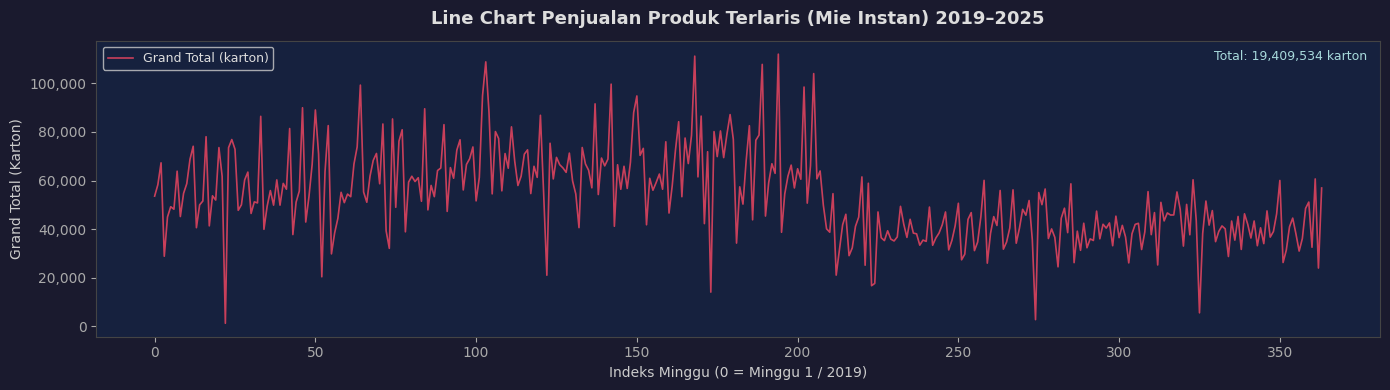

✅ Tersimpan: C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\outputs\figures\nb03_line_plot.png


In [4]:
# ── Line Chart Tren Penjualan 2019–2025 ──────────────────────
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(
    df_sorted.index,
    df_sorted["Grand Total"],
    color="#e94560",
    linewidth=1.2,
    alpha=0.85,
    label="Grand Total (karton)",
)

ax.set_title(
    "Line Chart Penjualan Produk Terlaris (Mie Instan) 2019–2025",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_xlabel("Indeks Minggu (0 = Minggu 1 / 2019)", fontsize=10)
ax.set_ylabel("Grand Total (Karton)", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(loc="upper left", fontsize=9)

# Annotasi total
ax.annotate(
    f"Total: {df_sorted['Grand Total'].sum():,.0f} karton",
    xy=(0.99, 0.97), xycoords="axes fraction",
    ha="right", va="top",
    fontsize=9, color="#a8dadc",
)

plt.tight_layout()

fig_path = PATHS["figures"] / "nb03_line_plot.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Tersimpan: {fig_path}")

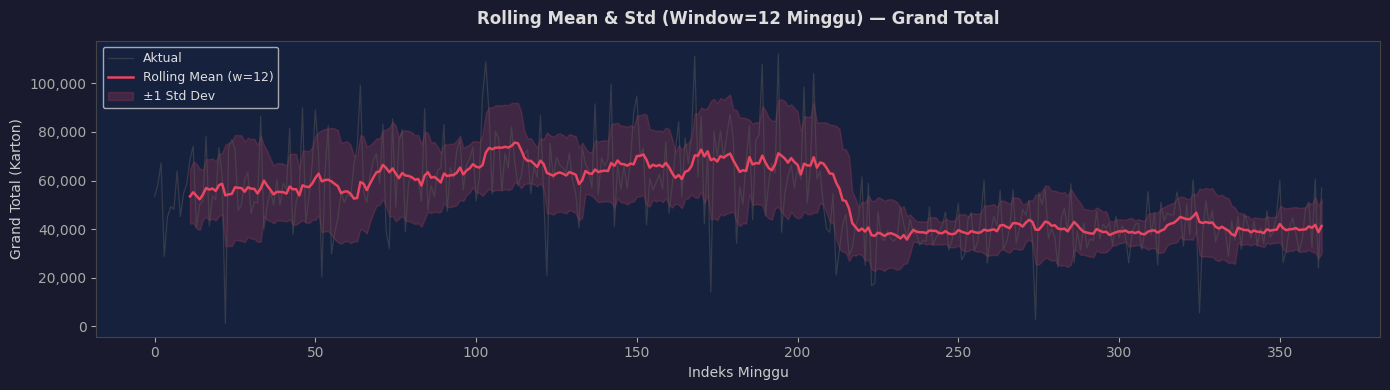

✅ Tersimpan: C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\outputs\figures\nb03_rolling_stats.png


In [5]:
# ── Rolling Statistics (Window 12 Minggu) ─────────────────────
rolling_window = 12
df_sorted["rolling_mean"] = df_sorted["Grand Total"].rolling(rolling_window).mean()
df_sorted["rolling_std"]  = df_sorted["Grand Total"].rolling(rolling_window).std()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_sorted.index, df_sorted["Grand Total"], color="#555", alpha=0.5, linewidth=0.9, label="Aktual")
ax.plot(df_sorted.index, df_sorted["rolling_mean"], color="#e94560", linewidth=1.8, label=f"Rolling Mean (w={rolling_window})")
ax.fill_between(
    df_sorted.index,
    df_sorted["rolling_mean"] - df_sorted["rolling_std"],
    df_sorted["rolling_mean"] + df_sorted["rolling_std"],
    alpha=0.2, color="#e94560", label="±1 Std Dev"
)
ax.set_title(f"Rolling Mean & Std (Window={rolling_window} Minggu) — Grand Total", fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Indeks Minggu", fontsize=10)
ax.set_ylabel("Grand Total (Karton)", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()

fig_path = PATHS["figures"] / "nb03_rolling_stats.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Tersimpan: {fig_path}")

# Hapus kolom sementara
df_sorted.drop(columns=["rolling_mean", "rolling_std"], inplace=True)

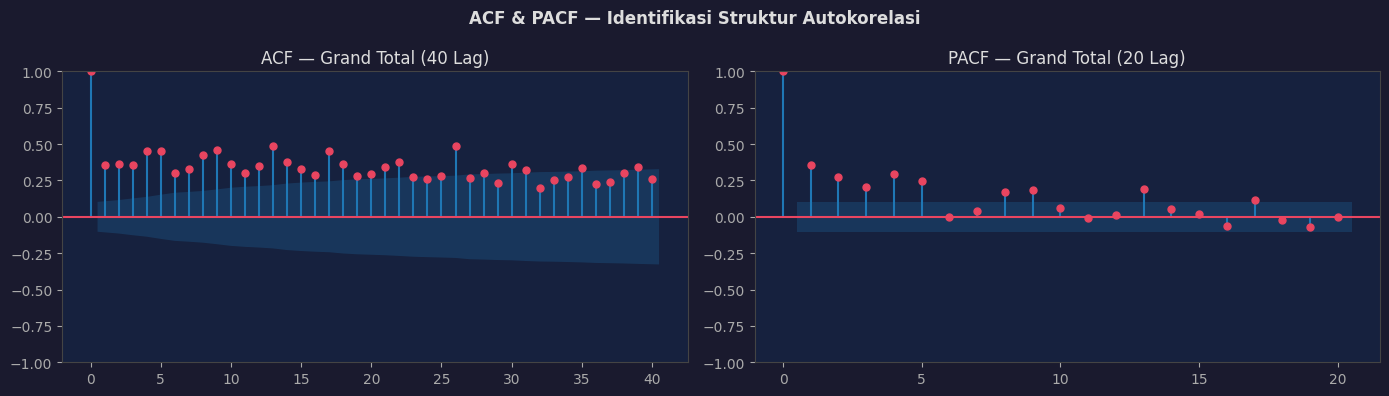

✅ Tersimpan: C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\outputs\figures\nb03_acf_pacf.png

  ℹ️  ACF memperlihatkan signifikansi autokorelasi hingga lag τ=8.
  ℹ️  PACF mengindikasikan ordo AR yang relevan untuk sliding window.


In [6]:
# ── ACF & PACF Plot ────────────────────────────────────────────
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf  # type: ignore[import-untyped]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df_sorted["Grand Total"], lags=40, ax=axes[0], color="#e94560",
         title="ACF — Grand Total (40 Lag)")
plot_pacf(df_sorted["Grand Total"], lags=20, ax=axes[1], color="#e94560",
          title="PACF — Grand Total (20 Lag)", method="ywm")

for ax in axes:
    ax.set_facecolor("#16213e")
    ax.tick_params(colors="#aaa")
    ax.title.set_color("#ddd")
    ax.xaxis.label.set_color("#ccc")
    ax.yaxis.label.set_color("#ccc")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444")

plt.suptitle("ACF & PACF — Identifikasi Struktur Autokorelasi", fontsize=12, fontweight="bold")
plt.tight_layout()

fig_path = PATHS["figures"] / "nb03_acf_pacf.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Tersimpan: {fig_path}")
print()
print("  ℹ️  ACF memperlihatkan signifikansi autokorelasi hingga lag τ=8.")
print("  ℹ️  PACF mengindikasikan ordo AR yang relevan untuk sliding window.")


In [7]:
# ── Uji Stasioneritas — ADF Test ───────────────────────────────
from statsmodels.tsa.stattools import adfuller  # type: ignore[import-untyped]

adf_result = adfuller(df_sorted["Grand Total"], autolag="AIC")
adf_stat, adf_pvalue, adf_lags, adf_nobs = adf_result[0], adf_result[1], adf_result[2], adf_result[3]
critical_vals = adf_result[4]

is_stationary = adf_pvalue < 0.05

print("=" * 65)
print("  UJI STASIONERITAS — Augmented Dickey-Fuller (ADF)")
print("=" * 65)
print(f"\n  ADF Statistic : {adf_stat:.6f}")
print(f"  p-value       : {adf_pvalue:.6f}")
print(f"  Lags Used     : {adf_lags}")
print(f"  Observations  : {adf_nobs}")
print()
print("  Nilai Kritis:")
for key, val in critical_vals.items():
    marker = "←" if adf_stat < val else "  "
    print(f"    {key:>5}: {val:.6f} {marker}")
print()
print(f"  Kesimpulan: {'✅ STASIONER (tolak H0)' if is_stationary else '⚠️  TIDAK STASIONER (gagal tolak H0)'}")
print(f"  (p-value {adf_pvalue:.4f} {'<' if is_stationary else '>='} 0.05)")
print()
if not is_stationary:
    print("  → Data non-stasioner: CNN-BiLSTM mampu mempelajari tren")
    print("    secara langsung dari fitur sliding window tanpa differencing.")
print("=" * 65)


  UJI STASIONERITAS — Augmented Dickey-Fuller (ADF)

  ADF Statistic : -1.334427
  p-value       : 0.613278
  Lags Used     : 12
  Observations  : 351

  Nilai Kritis:
       1%: -3.449119   
       5%: -2.869810   
      10%: -2.571176   

  Kesimpulan: ⚠️  TIDAK STASIONER (gagal tolak H0)
  (p-value 0.6133 >= 0.05)

  → Data non-stasioner: CNN-BiLSTM mampu mempelajari tren
    secara langsung dari fitur sliding window tanpa differencing.


## 📦 5. Distribusi & Boxplot

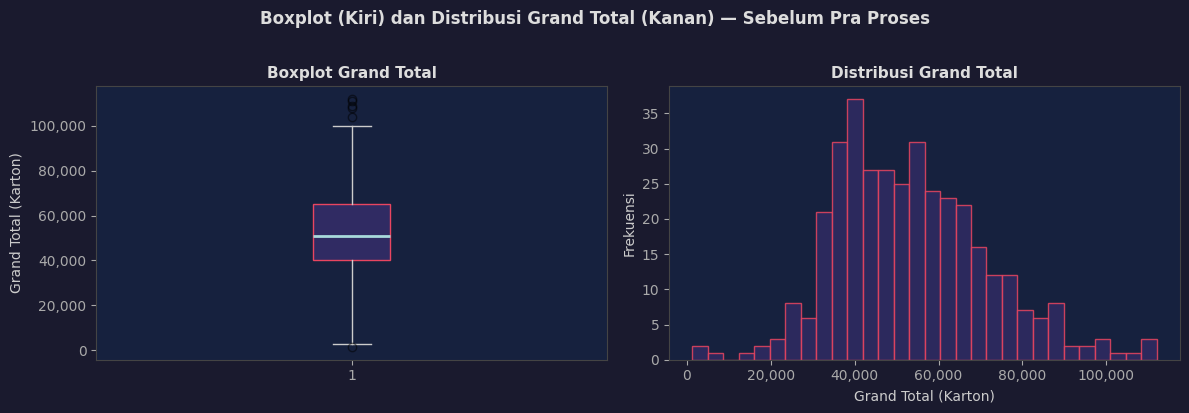

✅ Tersimpan: C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\outputs\figures\nb03_dist_boxplot.png


In [8]:
# ── Boxplot (kiri) + Histogram Distribusi (kanan) ─────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# — Boxplot ────────────────────────────────────────────────────
axes[0].boxplot(
    df_sorted["Grand Total"],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="#302b63", color="#e94560"),
    medianprops=dict(color="#a8dadc", linewidth=2),
    whiskerprops=dict(color="#ccc"),
    capprops=dict(color="#ccc"),
    flierprops=dict(marker="o", color="#e94560", alpha=0.5),
)
axes[0].set_title("Boxplot Grand Total", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Grand Total (Karton)", fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# — Histogram ──────────────────────────────────────────────────
axes[1].hist(
    df_sorted["Grand Total"],
    bins=30,
    color="#302b63",
    edgecolor="#e94560",
    alpha=0.85,
)
axes[1].set_title("Distribusi Grand Total", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Grand Total (Karton)", fontsize=10)
axes[1].set_ylabel("Frekuensi", fontsize=10)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.suptitle(
    "Boxplot (Kiri) dan Distribusi Grand Total (Kanan) — Sebelum Pra Proses",
    fontsize=12, fontweight="bold", y=1.02,
)
plt.tight_layout()

fig_path = PATHS["figures"] / "nb03_dist_boxplot.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Tersimpan: {fig_path}")

## 💡 6. Insight Data

In [9]:
# ── Insight & Deteksi Outlier IQR ────────────────────────────
q1  = df_sorted["Grand Total"].quantile(0.25)
q3  = df_sorted["Grand Total"].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
lower_fence = q1 - 1.5 * iqr

mask_outlier = (df_sorted["Grand Total"] > upper_fence) | (df_sorted["Grand Total"] < lower_fence)
n_outliers   = mask_outlier.sum()

print("=" * 65)
print("  INSIGHT EDA — Grand Total (Sebelum Pra Proses)")
print("=" * 65)
print(f"  Jumlah observasi   : {len(df_sorted):,} minggu (7 tahun × 52 minggu)")
print(f"  Total penjualan    : {df_sorted['Grand Total'].sum():,.0f} karton")
print(f"  Rata-rata (mean)   : {df_sorted['Grand Total'].mean():,.2f} karton/minggu")
print(f"  Median             : {df_sorted['Grand Total'].median():,.2f} karton/minggu")
print(f"  Std Deviasi        : {df_sorted['Grand Total'].std():,.2f}")
print(f"  Min / Max          : {df_sorted['Grand Total'].min():,.0f} / {df_sorted['Grand Total'].max():,.0f} karton")
print(f"  Q1 / Q3            : {q1:,.2f} / {q3:,.2f}")
print(f"  IQR                : {iqr:,.2f}")
print(f"  Batas bawah IQR    : {lower_fence:,.2f}")
print(f"  Batas atas IQR     : {upper_fence:,.2f}")
print(f"  Outlier terdeteksi : {n_outliers} minggu")
print(f"  Skewness           : {df_sorted['Grand Total'].skew():.4f}")
print(f"  Kurtosis           : {df_sorted['Grand Total'].kurtosis():.4f}")
print()
print("  Temuan Utama:")
print("  → Range nilai sangat lebar (min≈1.305 vs max≈112.040 karton).")
print("  → Distribusi right-skewed — beberapa minggu penjualan sangat")
print("    tinggi menarik nilai mean jauh di atas median.")
print(f"  → {n_outliers} data point melewati batas IQR — akan di-clipping")
print("    pada Notebook 04 (Outlier Handling IQR Clipping).")
print("=" * 65)

  INSIGHT EDA — Grand Total (Sebelum Pra Proses)
  Jumlah observasi   : 364 minggu (7 tahun × 52 minggu)
  Total penjualan    : 19,409,534 karton
  Rata-rata (mean)   : 53,322.90 karton/minggu
  Median             : 51,108.50 karton/minggu
  Std Deviasi        : 18,426.24
  Min / Max          : 1,305 / 112,040 karton
  Q1 / Q3            : 40,078.75 / 65,113.50
  IQR                : 25,034.75
  Batas bawah IQR    : 2,526.62
  Batas atas IQR     : 102,665.62
  Outlier terdeteksi : 6 minggu
  Skewness           : 0.4718
  Kurtosis           : 0.4369

  Temuan Utama:
  → Range nilai sangat lebar (min≈1.305 vs max≈112.040 karton).
  → Distribusi right-skewed — beberapa minggu penjualan sangat
    tinggi menarik nilai mean jauh di atas median.
  → 6 data point melewati batas IQR — akan di-clipping
    pada Notebook 04 (Outlier Handling IQR Clipping).


In [10]:
# ── Simpan EDA Profile ke JSON ────────────────────────────────
eda_profile = {
    "notebook"         : "NB03 — EDA Univariate Profile",
    "target_column"    : "Grand Total",
    "n_observations"   : int(len(df_sorted)),
    "total_sum_karton" : int(df_sorted["Grand Total"].sum()),
    "mean"             : round(float(df_sorted["Grand Total"].mean()), 4),
    "median"           : round(float(df_sorted["Grand Total"].median()), 4),
    "std"              : round(float(df_sorted["Grand Total"].std()), 4),
    "min"              : int(df_sorted["Grand Total"].min()),
    "max"              : int(df_sorted["Grand Total"].max()),
    "q1"               : round(float(q1), 4),
    "q3"               : round(float(q3), 4),
    "iqr"              : round(float(iqr), 4),
    "lower_fence"      : round(float(lower_fence), 4),
    "upper_fence"      : round(float(upper_fence), 4),
    "n_outliers"       : int(n_outliers),
    "skewness"         : round(float(df_sorted["Grand Total"].skew()), 4),
    "kurtosis"         : round(float(df_sorted["Grand Total"].kurtosis()), 4),
    "adf_pvalue"       : round(float(adf_pvalue), 6),
    "is_stationary"    : bool(is_stationary),
    "figures"          : {
        "line_plot"      : "outputs/figures/nb03_line_plot.png",
        "rolling_stats"  : "outputs/figures/nb03_rolling_stats.png",
        "acf_pacf"       : "outputs/figures/nb03_acf_pacf.png",
        "dist_boxplot"   : "outputs/figures/nb03_dist_boxplot.png",
    },
}

out_path = PATHS["logs"] / "eda_profile.json"
with open(out_path, "w") as f:
    json.dump(eda_profile, f, indent=2)
print(f"✅ EDA profile tersimpan: {out_path}")
print()
print(json.dumps(eda_profile, indent=2))

✅ EDA profile tersimpan: C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\logs\eda_profile.json

{
  "notebook": "NB03 \u2014 EDA Univariate Profile",
  "target_column": "Grand Total",
  "n_observations": 364,
  "total_sum_karton": 19409534,
  "mean": 53322.8956,
  "median": 51108.5,
  "std": 18426.2445,
  "min": 1305,
  "max": 112040,
  "q1": 40078.75,
  "q3": 65113.5,
  "iqr": 25034.75,
  "lower_fence": 2526.625,
  "upper_fence": 102665.625,
  "n_outliers": 6,
  "skewness": 0.4718,
  "kurtosis": 0.4369,
  "adf_pvalue": 0.613278,
  "is_stationary": false,
  "figures": {
    "line_plot": "outputs/figures/nb03_line_plot.png",
    "rolling_stats": "outputs/figures/nb03_rolling_stats.png",
    "acf_pacf": "outputs/figures/nb03_acf_pacf.png",
    "dist_boxplot": "outputs/figures/nb03_dist_boxplot.png"
  }
}


In [11]:
# ── Checklist Akhir Notebook 03 ──────────────────────────────
checklist = [
    ("Statistik ringkas tersedia",   True),
    ("Plot tren waktu tersimpan",    (PATHS["figures"] / "nb03_line_plot.png").exists()),
    ("Rolling statistics tersimpan", (PATHS["figures"] / "nb03_rolling_stats.png").exists()),
    ("ACF/PACF plot tersimpan",      (PATHS["figures"] / "nb03_acf_pacf.png").exists()),
    ("Plot distribusi tersimpan",    (PATHS["figures"] / "nb03_dist_boxplot.png").exists()),
    ("Plot boxplot tersimpan",       (PATHS["figures"] / "nb03_dist_boxplot.png").exists()),
    ("EDA profile JSON tersimpan",   (PATHS["logs"] / "eda_profile.json").exists()),
    ("Uji stasioneritas ADF dilakukan", True),
    ("Insight data tertulis",        True),
]

print("=" * 60)
print("  CHECKLIST NOTEBOOK 03")
print("=" * 60)
print()
for item, passed in checklist:
    sym = "✅" if passed else "❌"
    print(f"  {sym}  {item}")

all_pass = all(v for _, v in checklist)
print()
print("=" * 60)
if all_pass:
    print("  ✅ SEMUA CHECKLIST LULUS — Notebook 03 selesai!")
    print("     Lanjutkan ke Notebook 04 — Outlier Handling IQR Clipping.")
else:
    print("  ❌ ADA CHECKLIST GAGAL — Investigasi sebelum lanjut!")
print("=" * 60)
print()

  CHECKLIST NOTEBOOK 03

  ✅  Statistik ringkas tersedia
  ✅  Plot tren waktu tersimpan
  ✅  Rolling statistics tersimpan
  ✅  ACF/PACF plot tersimpan
  ✅  Plot distribusi tersimpan
  ✅  Plot boxplot tersimpan
  ✅  EDA profile JSON tersimpan
  ✅  Uji stasioneritas ADF dilakukan
  ✅  Insight data tertulis

  ✅ SEMUA CHECKLIST LULUS — Notebook 03 selesai!
     Lanjutkan ke Notebook 04 — Outlier Handling IQR Clipping.



---

## 🔗 Navigasi Pipeline

| | Notebook |
|--|----------|
| ← | **[02 - Time Index Integrity Audit](./02%20-%20Time%20Index%20Integrity%20Audit.ipynb)** |
| **→** | **[04 - Outlier Handling IQR Clipping](./04%20-%20Outlier%20Handling%20IQR%20Clipping.ipynb)** |

---

### 📎 Variabel Penting yang Dihasilkan Notebook Ini

Variabel berikut tersedia untuk notebook selanjutnya (dimuat ulang dari file atau dihitung kembali):

```python
df_sorted    # DataFrame terurut Year ↑, Week ↑ — shape (364, 3)
             # Kolom: Year (int), Week (int), Grand Total (int)
eda_profile  # dict statistik deskriptif + path figure + deteksi outlier
PATHS        # dict path pipeline (sama seperti Notebook 00–02)
```

---

<div style="text-align: center; color: #888; font-size: 0.85em; padding: 12px 0;">
Notebook 03 — EDA Univariate Profile &nbsp;|&nbsp;
CNN–BiLSTM + GA Sales Forecasting &nbsp;|&nbsp;
Departemen Sistem Informasi ITS Surabaya &nbsp;|&nbsp; 2025
</div>